# Notebook 12 — Modelado de clasificación binaria trimestral

A partir del dataset final de modelado construido en el notebook 11, este notebook entrena y compara varios clasificadores sencillos para distinguir entre trimestres con baja actividad documentada (`low`) y trimestres con actividad documentada (`active`) en Valmayor.

La clase `active` agrupa los niveles originales `medium` y `high`. Esta reformulación binaria se adopta porque el conjunto de datos contiene pocos registros trimestrales y la clase `high` aparece muy pocas veces, lo que dificulta una clasificación multiclase robusta.

El objetivo no es maximizar artificialmente la precisión, sino evaluar si las variables externas disponibles contienen señal suficiente para diferenciar entre baja actividad y actividad documentada, manteniendo un planteamiento interpretable y defendible para el TFG.

## Preparación del entorno

Se monta Google Drive y se importan las librerías necesarias para cargar los datos, realizar un análisis exploratorio previo y entrenar varios modelos de clasificación.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Rutas de entrada y salida

Se define la ruta del dataset final de modelado generado en el notebook 11 y la carpeta de salida donde se guardarán las métricas y resultados de este notebook.

In [3]:
BASE_DIR = Path("/content/drive/MyDrive/PIDS4jjj2")
OUT_DIR = BASE_DIR / "outputs" / "llm_activity"

MODEL_DATASET_PATH = OUT_DIR / "valmayor_modeling_dataset.parquet"
METRICS_OUTPUT_PATH = OUT_DIR / "valmayor_classification_metrics.csv"

print("MODEL_DATASET_PATH:", MODEL_DATASET_PATH)
print("METRICS_OUTPUT_PATH:", METRICS_OUTPUT_PATH)

MODEL_DATASET_PATH: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_modeling_dataset.parquet
METRICS_OUTPUT_PATH: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_classification_metrics.csv


## Carga del dataset de modelado

Se carga la tabla final trimestral, que ya integra la variable objetivo de clasificación y las variables externas construidas en los notebooks previos.

In [4]:
df = pd.read_parquet(MODEL_DATASET_PATH)
df.head()

,year,year_quarter,n_videos,mean_activity_mentions,share_low,share_medium,share_high,share_certainty_high,captures_nonnull_mean,target_class,...,quarter,pressure_msl_mean_quarter,pressure_msl_min_quarter,pressure_msl_max_quarter,pressure_msl_std_quarter,surface_pressure_mean_quarter,surface_pressure_min_quarter,surface_pressure_max_quarter,surface_pressure_std_quarter,n_obs_pressure_quarter
0,2009.0,2009-Q3,2,1.0,1.0,0.0,0.0,0.0,NaN,low,...,3,1016.347826,1009.3,1023.1,3.078657,925.219565,916.7,930.6,2.812657,92
1,2009.0,2009-Q4,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,...,4,1016.265217,990.5,1031.3,7.303385,920.971739,897.5,933.8,7.262705,92
2,2010.0,2010-Q1,1,1.0,1.0,0.0,0.0,0.0,NaN,low,...,1,1014.594444,992.6,1026.5,7.834415,917.790000,897.3,929.5,7.288348,90
3,2010.0,2010-Q2,2,1.0,0.0,1.0,0.0,0.5,1.0,medium,...,2,1015.339560,1002.6,1025.2,5.070719,921.686813,909.5,931.1,5.109908,91
4,2011.0,2011-Q1,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,...,1,1020.051111,1000.8,1034.0,7.409184,923.067778,904.6,935.4,6.919129,90


## Inspección general del dataset

Antes del modelado se revisa el número de trimestres disponibles, el rango temporal cubierto y las columnas presentes en la tabla final.

In [5]:
print("Shape:", df.shape)
print("Número de trimestres:", df["year_quarter"].nunique())
print("Periodo:", df["year_quarter"].min(), "->", df["year_quarter"].max())
print("\nColumnas:")
print(df.columns.tolist())

Shape: (54, 41)
Número de trimestres: 54
Periodo: 2009-Q3 -> 2026-Q2

Columnas:
['year', 'year_quarter', 'n_videos', 'mean_activity_mentions', 'share_low', 'share_medium', 'share_high', 'share_certainty_high', 'captures_nonnull_mean', 'target_class', 'target_class_id', 'quarter_x', 'temp_mean_quarter', 'temp_max_mean_quarter', 'temp_min_mean_quarter', 'precip_sum_quarter', 'rain_sum_quarter', 'snowfall_sum_quarter', 'wind_max_mean_quarter', 'radiation_sum_quarter', 'eto_sum_quarter', 'quarter_y', 'agua_total_mean_quarter', 'agua_total_min_quarter', 'agua_total_max_quarter', 'agua_total_std_quarter', 'agua_actual_mean_quarter', 'agua_actual_min_quarter', 'agua_actual_max_quarter', 'agua_actual_std_quarter', 'n_obs_embalse_quarter', 'quarter', 'pressure_msl_mean_quarter', 'pressure_msl_min_quarter', 'pressure_msl_max_quarter', 'pressure_msl_std_quarter', 'surface_pressure_mean_quarter', 'surface_pressure_min_quarter', 'surface_pressure_max_quarter', 'surface_pressure_std_quarter', 'n_obs

## Distribución de la variable objetivo binaria

Antes de entrenar los modelos se transforma la variable objetivo original (`low`, `medium`, `high`) en una variable binaria.

La clase `low` se mantiene como baja actividad documentada, mientras que `medium` y `high` se agrupan en una única clase `active`. Esta decisión reduce el problema de escasez de ejemplos en la clase `high` y genera una formulación más estable para un dataset trimestral pequeño.

In [6]:
# Variable objetivo binaria:
# low -> low
# medium/high -> active

df["target_binary"] = np.where(df["target_class"] == "low", "low", "active")

print("Distribución original:")
display(df["target_class"].value_counts())

print("\nDistribución binaria:")
display(df["target_binary"].value_counts())

Distribución original:


,count
target_class,
low,28
medium,22
high,4



Distribución binaria:


,count
target_binary,
low,28
active,26


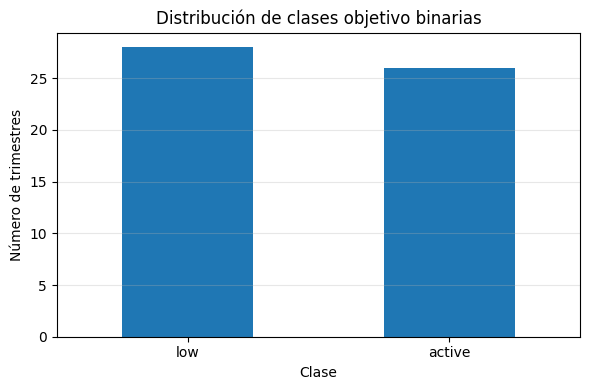

In [7]:
plt.figure(figsize=(6, 4))
df["target_binary"].value_counts().loc[["low", "active"]].plot(kind="bar")
plt.title("Distribución de clases objetivo binarias")
plt.xlabel("Clase")
plt.ylabel("Número de trimestres")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Selección de variables predictoras

En esta fase se utilizan únicamente variables ambientales externas como entrada del modelo. No se incluyen variables derivadas directamente de la actividad de YouTube, como número de vídeos o proporciones de menciones, porque el objetivo es comprobar si el contexto ambiental aporta señal para distinguir entre trimestres de baja actividad y trimestres con actividad documentada.

Tampoco se incluye la variable `year`, ya que el modelo final se orienta al análisis de escenarios ambientales. De esta forma, las predicciones dependen únicamente de condiciones meteorológicas, hidrológicas y atmosféricas, y no de una tendencia temporal explícita.

Dado que el dataset contiene un número reducido de observaciones trimestrales, se utiliza un conjunto reducido de variables representativas. Esto permite limitar el riesgo de sobreajuste, reducir redundancia entre predictores y mantener una interpretación clara del modelo.

In [8]:
TARGET_COL = "target_binary"

candidate_feature_cols = [
    # Meteo
    "temp_mean_quarter",
    "precip_sum_quarter",
    "wind_max_mean_quarter",

    # Hidrología
    "agua_actual_mean_quarter",

    # Presión atmosférica
    "pressure_msl_mean_quarter",
]

feature_cols = [c for c in candidate_feature_cols if c in df.columns]
missing_cols = [c for c in candidate_feature_cols if c not in df.columns]

print("Variables predictoras utilizadas:")
print(feature_cols)

if missing_cols:
    print("\nVariables no encontradas en el dataset:")
    print(missing_cols)

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribución objetivo binaria:")
display(y.value_counts())

Variables predictoras utilizadas:
['temp_mean_quarter', 'precip_sum_quarter', 'wind_max_mean_quarter', 'agua_actual_mean_quarter', 'pressure_msl_mean_quarter']

Shape X: (54, 5)
Shape y: (54,)

Distribución objetivo binaria:


,count
target_binary,
low,28
active,26


## Análisis exploratorio previo

Antes del entrenamiento se revisan las variables predictoras seleccionadas. El objetivo es comprobar su disponibilidad, su escala y su relación descriptiva con las clases binarias `low` y `active`.

Este análisis es descriptivo y no implica causalidad.

In [9]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Número de variables numéricas:", len(numeric_cols))
print(numeric_cols)

display(X.describe().T)

Número de variables numéricas: 5
['temp_mean_quarter', 'precip_sum_quarter', 'wind_max_mean_quarter', 'agua_actual_mean_quarter', 'pressure_msl_mean_quarter']


,count,mean,std,min,25%,50%,75%,max
temp_mean_quarter,54.0,14.577137,6.680813,4.318889,9.436413,14.570330,22.564402,24.829348
precip_sum_quarter,54.0,142.622222,88.842187,10.700000,74.800000,133.600000,204.925000,431.100000
wind_max_mean_quarter,54.0,15.669125,1.802020,10.766304,14.374728,15.716111,16.837428,19.948889
agua_actual_mean_quarter,54.0,89.777930,16.429996,51.307692,79.230769,90.846154,103.081731,118.538462
pressure_msl_mean_quarter,54.0,1017.446505,2.657254,1013.753846,1015.696978,1016.357430,1019.257065,1023.798889


## Correlación entre variables predictoras

Se revisa la correlación lineal entre las variables ambientales seleccionadas. Esto permite detectar posibles relaciones fuertes entre predictores y valorar si el conjunto de variables es razonablemente compacto.

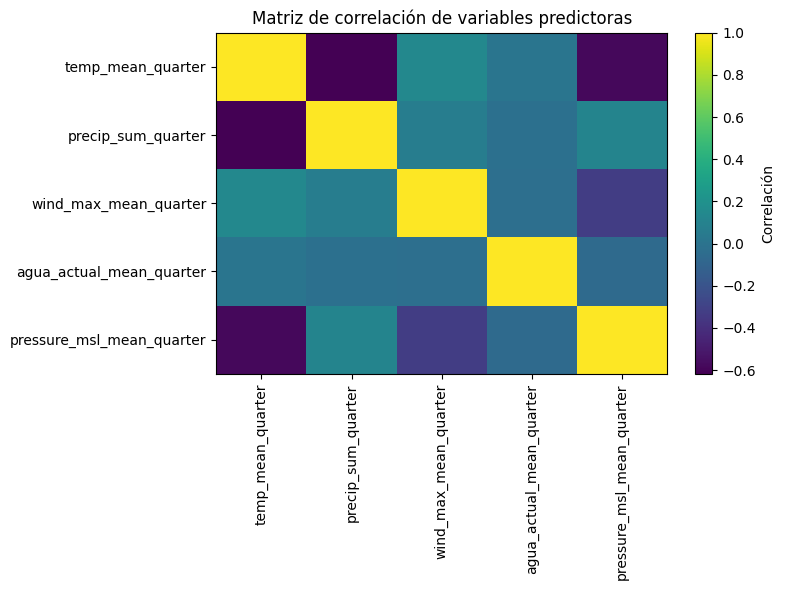

,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
temp_mean_quarter,1.000000,-0.617466,0.139662,0.012422,-0.583220
precip_sum_quarter,-0.617466,1.000000,0.066485,-0.020504,0.110248
wind_max_mean_quarter,0.139662,0.066485,1.000000,-0.025279,-0.320934
agua_actual_mean_quarter,0.012422,-0.020504,-0.025279,1.000000,-0.061081
pressure_msl_mean_quarter,-0.583220,0.110248,-0.320934,-0.061081,1.000000


In [10]:
corr_matrix = X[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Matriz de correlación de variables predictoras")
plt.tight_layout()
plt.show()

corr_matrix

## Relación descriptiva entre variables ambientales y clases objetivo

Se calcula la media de cada variable predictora para las clases `low` y `active`. Esta comparación permite revisar si existen diferencias descriptivas entre trimestres de baja actividad documentada y trimestres con actividad documentada.

In [11]:
group_summary = (
    df.groupby(TARGET_COL)[feature_cols]
    .mean(numeric_only=True)
    .T
)

if set(["low", "active"]).issubset(group_summary.columns):
    group_summary["active_minus_low"] = group_summary["active"] - group_summary["low"]
    group_summary["abs_difference"] = group_summary["active_minus_low"].abs()

display(
    group_summary
    .sort_values("abs_difference", ascending=False)
    .round(3)
)

target_binary,active,low,active_minus_low,abs_difference
precip_sum_quarter,157.969,128.371,29.598,29.598
temp_mean_quarter,12.431,16.570,-4.138,4.138
pressure_msl_mean_quarter,1018.395,1016.566,1.829,1.829
agua_actual_mean_quarter,90.388,89.212,1.176,1.176
wind_max_mean_quarter,15.267,16.043,-0.776,0.776


## Partición temporal entrenamiento-prueba

Para respetar la naturaleza temporal del problema, los datos se ordenan cronológicamente y se reserva el tramo más reciente como conjunto de prueba final.

Esta partición simula un escenario en el que el modelo se entrena con información pasada y se evalúa sobre trimestres posteriores. Dado que el conjunto de prueba contiene pocos trimestres, sus resultados se interpretan como una evaluación descriptiva.

In [12]:
N_TEST = 8

df_sorted = df.sort_values(["year", "year_quarter"]).reset_index(drop=True)

train_df = df_sorted.iloc[:-N_TEST].copy()
test_df = df_sorted.iloc[-N_TEST:].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

print("Periodo de entrenamiento:", train_df["year_quarter"].min(), "->", train_df["year_quarter"].max())
print("Periodo de prueba:", test_df["year_quarter"].min(), "->", test_df["year_quarter"].max())

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
display(y_train.value_counts())

print("\nDistribución en prueba:")
display(y_test.value_counts())

Periodo de entrenamiento: 2009-Q3 -> 2023-Q4
Periodo de prueba: 2024-Q1 -> 2026-Q2

X_train: (46, 5)
X_test: (8, 5)

Distribución en entrenamiento:


,count
target_binary,
low,23
active,23



Distribución en prueba:


,count
target_binary,
low,5
active,3


## Modelo de clasificación

Se comparan varios modelos sencillos para disponer de una referencia de rendimiento: un modelo Dummy, Logistic Regression, Decision Tree y Random Forest.

El modelo Dummy funciona como línea base mínima. Decision Tree y Random Forest se incluyen como comparación no lineal. No obstante, el modelo principal del notebook será Logistic Regression, porque es más sencillo, interpretable y adecuado para un dataset pequeño. Además, permite obtener probabilidades de pertenencia a la clase `active`, que serán utilizadas posteriormente en el análisis de escenarios.

In [13]:
models = {
    "Dummy": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

models.keys()

dict_keys(['Dummy', 'Logistic Regression', 'Decision Tree', 'Random Forest'])

## Evaluación en el test temporal final

Se entrena cada modelo con el bloque histórico de entrenamiento y se evalúa sobre los últimos trimestres reservados como test final.

Se utilizan `accuracy`, `balanced_accuracy` y `f1_macro`. La métrica `f1_macro` es especialmente relevante porque da el mismo peso a las dos clases (`low` y `active`), algo importante cuando el conjunto de prueba contiene pocos trimestres.

In [14]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "y_pred": y_pred,
    }


fixed_results = {}

for model_name, model in models.items():
    fixed_results[model_name] = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

metrics_df = pd.DataFrame([
    {
        "model": model_name,
        "accuracy": result["accuracy"],
        "balanced_accuracy": result["balanced_accuracy"],
        "f1_macro": result["f1_macro"],
    }
    for model_name, result in fixed_results.items()
]).sort_values("f1_macro", ascending=False).reset_index(drop=True)

metrics_df

,model,accuracy,balanced_accuracy,f1_macro
0,Logistic Regression,0.625,0.700000,0.619048
1,Random Forest,0.500,0.466667,0.466667
2,Decision Tree,0.375,0.366667,0.365079
3,Dummy,0.375,0.500000,0.272727


## Validación cruzada temporal

Además del test final, se utiliza `TimeSeriesSplit` para evaluar los modelos en varios cortes cronológicos. Esta validación respeta el orden temporal de los trimestres y permite obtener una referencia más estable que una única partición final.

Dado el tamaño reducido del dataset, los resultados se interpretan como una comparación exploratoria entre modelos, no como una estimación definitiva de rendimiento operativo.

In [15]:
from sklearn.model_selection import TimeSeriesSplit

X_cv = df_sorted[feature_cols].copy()
y_cv = df_sorted[TARGET_COL].copy()

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for model_name, model in models.items():
    for fold_id, (train_idx, val_idx) in enumerate(tscv.split(X_cv), start=1):
        X_tr, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        cv_results.append({
            "fold": fold_id,
            "model": model_name,
            "accuracy": accuracy_score(y_val, y_val_pred),
            "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred),
            "f1_macro": f1_score(y_val, y_val_pred, average="macro", zero_division=0),
            "train_start": df_sorted.iloc[train_idx]["year_quarter"].min(),
            "train_end": df_sorted.iloc[train_idx]["year_quarter"].max(),
            "val_start": df_sorted.iloc[val_idx]["year_quarter"].min(),
            "val_end": df_sorted.iloc[val_idx]["year_quarter"].max(),
        })

tscv_results_df = pd.DataFrame(cv_results)

tscv_metrics_df = (
    tscv_results_df
    .groupby("model", as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
    )
    .sort_values("f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

tscv_metrics_df

,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_macro_std
0,Random Forest,0.577778,0.610000,0.561104,0.154931
1,Logistic Regression,0.600000,0.590000,0.559997,0.176104
2,Decision Tree,0.533333,0.538333,0.504444,0.188455
3,Dummy,0.377778,0.500000,0.271429,0.047916


## Comparación global de modelos

Se comparan los resultados del test temporal final con los resultados medios de la validación cruzada temporal. Esta tabla permite revisar si un modelo funciona bien únicamente en el tramo final o si mantiene un comportamiento razonable en varios cortes cronológicos.

Aunque Random Forest obtiene una media ligeramente superior en `TimeSeriesSplit`, la diferencia con Logistic Regression es muy pequeña. Por ello, la selección final también tiene en cuenta la simplicidad, interpretabilidad y utilidad del modelo para el análisis posterior de escenarios.

In [16]:
comparison_metrics_df = metrics_df.merge(
    tscv_metrics_df[[
        "model",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "f1_macro_mean",
        "f1_macro_std"
    ]],
    on="model",
    how="left"
)

comparison_metrics_df = comparison_metrics_df.rename(columns={
    "accuracy": "fixed_test_accuracy",
    "balanced_accuracy": "fixed_test_balanced_accuracy",
    "f1_macro": "fixed_test_f1_macro",
    "accuracy_mean": "tscv_accuracy_mean",
    "balanced_accuracy_mean": "tscv_balanced_accuracy_mean",
    "f1_macro_mean": "tscv_f1_macro_mean",
    "f1_macro_std": "tscv_f1_macro_std",
})

comparison_metrics_df

,model,fixed_test_accuracy,fixed_test_balanced_accuracy,fixed_test_f1_macro,tscv_accuracy_mean,tscv_balanced_accuracy_mean,tscv_f1_macro_mean,tscv_f1_macro_std
0,Logistic Regression,0.625,0.700000,0.619048,0.600000,0.590000,0.559997,0.176104
1,Random Forest,0.500,0.466667,0.466667,0.577778,0.610000,0.561104,0.154931
2,Decision Tree,0.375,0.366667,0.365079,0.533333,0.538333,0.504444,0.188455
3,Dummy,0.375,0.500000,0.272727,0.377778,0.500000,0.271429,0.047916


## Selección del modelo final

Aunque se comparan varios modelos, el modelo final del notebook es Logistic Regression.

Esta elección se basa en tres motivos principales:

- obtiene un rendimiento prácticamente equivalente al mejor modelo en validación cruzada temporal;
- es más sencillo e interpretable para un dataset reducido;
- permite obtener probabilidades de pertenencia a la clase `active`, que serán utilizadas en el análisis posterior de escenarios.

Random Forest se mantiene como modelo comparativo, pero no se adopta como modelo final porque su mejora media es mínima y su interpretación es menos directa.

In [17]:
final_model_name = "Logistic Regression"
final_model = models[final_model_name]

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

final_metrics_df = pd.DataFrame([{
    "model": final_model_name,
    "accuracy": accuracy_score(y_test, final_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, final_pred),
    "f1_macro": f1_score(y_test, final_pred, average="macro", zero_division=0),
}])

final_metrics_df

,model,accuracy,balanced_accuracy,f1_macro
0,Logistic Regression,0.625,0.7,0.619048


## Evaluación detallada del modelo final

Se muestra la matriz de confusión y el informe de clasificación del modelo final sobre el test temporal. Estos resultados permiten revisar qué clases se aciertan y cuáles se confunden.

Debido al reducido número de trimestres en el test final, esta evaluación debe interpretarse como una lectura descriptiva y no como una estimación robusta de rendimiento operativo.

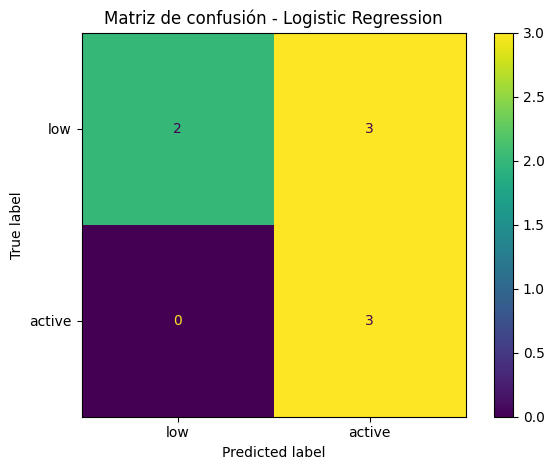

              precision    recall  f1-score   support

         low       1.00      0.40      0.57         5
      active       0.50      1.00      0.67         3

    accuracy                           0.62         8
   macro avg       0.75      0.70      0.62         8
weighted avg       0.81      0.62      0.61         8



In [18]:
class_order = ["low", "active"]

cm = confusion_matrix(y_test, final_pred, labels=class_order)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Logistic Regression")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    final_pred,
    labels=class_order,
    zero_division=0
))

## Comparación entre clases reales y predichas

La siguiente tabla muestra, para cada trimestre del conjunto de prueba, la clase real y la clase predicha por el modelo final. También se incluye si la predicción ha sido correcta o no.

Esta tabla permite revisar de forma directa el comportamiento del modelo en el tramo temporal final.

In [19]:
comparison_df = test_df[[
    "year",
    "year_quarter",
    TARGET_COL
]].copy()

comparison_df = comparison_df.rename(columns={
    TARGET_COL: "y_true"
})

comparison_df["y_pred"] = final_pred
comparison_df["correct"] = comparison_df["y_true"] == comparison_df["y_pred"]

comparison_df

,year,year_quarter,y_true,y_pred,correct
46,2024.0,2024-Q1,low,active,False
47,2024.0,2024-Q3,low,low,True
48,2025.0,2025-Q1,active,active,True
49,2025.0,2025-Q2,active,active,True
50,2025.0,2025-Q3,low,low,True
51,2025.0,2025-Q4,low,active,False
52,2026.0,2026-Q1,low,active,False
53,2026.0,2026-Q2,active,active,True


## Comparación de predicciones entre modelos

Además del modelo final, se revisan las predicciones de todos los modelos en el test temporal. Esta comparación ayuda a identificar si las diferencias entre modelos se deben a trimestres concretos.

In [20]:
all_predictions = []

for model_name, result in fixed_results.items():
    temp_df = test_df[[
        "year",
        "year_quarter",
        TARGET_COL
    ]].copy()

    temp_df = temp_df.rename(columns={
        TARGET_COL: "y_true"
    })

    temp_df["y_pred"] = result["y_pred"]
    temp_df["correct"] = temp_df["y_true"] == temp_df["y_pred"]
    temp_df["model"] = model_name

    all_predictions.append(temp_df)

all_predictions_df = pd.concat(all_predictions, ignore_index=True)

all_predictions_df

,year,year_quarter,y_true,y_pred,correct,model
0,2024.0,2024-Q1,low,active,False,Dummy
1,2024.0,2024-Q3,low,active,False,Dummy
2,2025.0,2025-Q1,active,active,True,Dummy
3,2025.0,2025-Q2,active,active,True,Dummy
4,2025.0,2025-Q3,low,active,False,Dummy
5,2025.0,2025-Q4,low,active,False,Dummy
6,2026.0,2026-Q1,low,active,False,Dummy
7,2026.0,2026-Q2,active,active,True,Dummy
8,2024.0,2024-Q1,low,active,False,Logistic Regression
9,2024.0,2024-Q3,low,low,True,Logistic Regression


## Probabilidad estimada de actividad documentada

Además de la clase predicha, se calcula la probabilidad estimada de pertenecer a la clase `active`. Esta probabilidad será la salida principal utilizada en el notebook posterior de escenarios.

In [21]:
proba = final_model.predict_proba(X_test)
class_labels = final_model.named_steps["model"].classes_
active_idx = list(class_labels).index("active")

comparison_df["p_active"] = proba[:, active_idx]
comparison_df["model"] = final_model_name

comparison_df

,year,year_quarter,y_true,y_pred,correct,p_active,model
46,2024.0,2024-Q1,low,active,False,0.686025,Logistic Regression
47,2024.0,2024-Q3,low,low,True,0.155165,Logistic Regression
48,2025.0,2025-Q1,active,active,True,0.803484,Logistic Regression
49,2025.0,2025-Q2,active,active,True,0.538290,Logistic Regression
50,2025.0,2025-Q3,low,low,True,0.300607,Logistic Regression
51,2025.0,2025-Q4,low,active,False,0.691293,Logistic Regression
52,2026.0,2026-Q1,low,active,False,0.624696,Logistic Regression
53,2026.0,2026-Q2,active,active,True,0.520064,Logistic Regression


In [26]:
logreg = final_model.named_steps["model"]
print(logreg.classes_)

['active' 'low']


## Interpretación de coeficientes

Los coeficientes de Logistic Regression se reorientan para representar su efecto hacia la clase `active`.

Un coeficiente positivo indica que valores mayores de esa variable desplazan la predicción hacia `active`, mientras que un coeficiente negativo indica que valores mayores desplazan la predicción hacia `low`.

Esta interpretación es exploratoria y no debe entenderse como causalidad.

Clases internas del modelo: ['active', 'low']
Los coeficientes originales apuntan hacia: low


,feature,coefficient_towards_active,abs_coefficient
4,pressure_msl_mean_quarter,0.495455,0.495455
0,temp_mean_quarter,-0.338589,0.338589
2,wind_max_mean_quarter,-0.169250,0.169250
1,precip_sum_quarter,0.159881,0.159881
3,agua_actual_mean_quarter,0.141969,0.141969


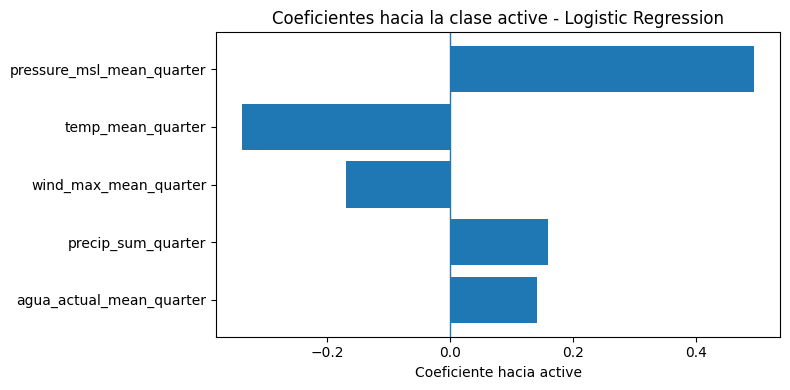

In [23]:
logreg = final_model.named_steps["model"]

classes = list(logreg.classes_)
raw_coef = logreg.coef_[0]

print("Clases internas del modelo:", classes)
print("Los coeficientes originales apuntan hacia:", classes[1])

# En LogisticRegression binaria, coef_[0] apunta hacia classes_[1].
# Como en este caso classes_[1] = "low", se invierte el signo para interpretarlo hacia "active".
if classes[1] == "active":
    coef_towards_active = raw_coef
else:
    coef_towards_active = -raw_coef

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient_towards_active": coef_towards_active,
})

coef_df["abs_coefficient"] = coef_df["coefficient_towards_active"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(8, 4))
plt.barh(coef_df["feature"], coef_df["coefficient_towards_active"])
plt.axvline(0, linewidth=1)
plt.gca().invert_yaxis()
plt.title("Coeficientes hacia la clase active - Logistic Regression")
plt.xlabel("Coeficiente hacia active")
plt.tight_layout()
plt.show()

## Plantilla de entrada para escenarios

Se genera una plantilla con las variables ambientales que deberá utilizar el notebook posterior de escenarios. Cada fila representará un perfil ambiental hipotético y el modelo devolverá la probabilidad estimada de actividad documentada.

In [24]:
scenario_template_df = pd.DataFrame([{
    col: X_train[col].median()
    for col in feature_cols
}])

scenario_template_df

,temp_mean_quarter,precip_sum_quarter,wind_max_mean_quarter,agua_actual_mean_quarter,pressure_msl_mean_quarter
0,14.57033,125.05,15.623406,88.576923,1016.306522


## Guardado de artefactos para escenarios

Se guardan únicamente los elementos necesarios para el notebook posterior de escenarios: el modelo final, la lista de variables utilizadas, las métricas principales, las predicciones del test, los coeficientes y una plantilla de entrada.

También se guardan las tablas comparativas de modelos como soporte metodológico, aunque el modelo utilizado en escenarios será Logistic Regression.

In [25]:
# Guardado de artefactos necesarios para el notebook de escenarios

import json
import joblib

OUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUT_DIR / "valmayor_binary_scenario_model_logreg_no_year.joblib"
features_path = OUT_DIR / "valmayor_binary_scenario_feature_cols.json"
template_path = OUT_DIR / "valmayor_binary_scenario_input_template.csv"
coefficients_path = OUT_DIR / "valmayor_binary_scenario_model_coefficients.csv"
metrics_path = OUT_DIR / "valmayor_binary_scenario_model_metrics.csv"

# 1. Modelo final entrenado
joblib.dump(final_model, model_path)

# 2. Variables que deberá usar el notebook de escenarios
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

# 3. Plantilla base para construir escenarios
scenario_template_df.to_csv(template_path, index=False, encoding="utf-8")

# 4. Coeficientes del modelo para interpretación
coef_df.to_csv(coefficients_path, index=False, encoding="utf-8")

# 5. Métricas principales del modelo final
final_metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")

print("Artefactos guardados para el notebook de escenarios:\n")

print("Modelo:")
print(model_path)

print("\nVariables del modelo:")
print(features_path)

print("\nPlantilla de escenarios:")
print(template_path)

print("\nCoeficientes:")
print(coefficients_path)

print("\nMétricas:")
print(metrics_path)

Artefactos guardados para el notebook de escenarios:

Modelo:
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_logreg_no_year.joblib

Variables del modelo:
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_feature_cols.json

Plantilla de escenarios:
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_input_template.csv

Coeficientes:
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_coefficients.csv

Métricas:
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_binary_scenario_model_metrics.csv


## Conclusión del notebook

Este notebook reformula el problema de clasificación trimestral como una tarea binaria entre `low` y `active`. Esta formulación resulta más estable que la clasificación multiclase original, ya que evita entrenar una clase `high` con muy pocos ejemplos.

El modelo utiliza únicamente variables ambientales: temperatura media, precipitación acumulada, viento máximo medio, nivel medio del embalse y presión atmosférica media. La variable `year` no se incluye porque el objetivo posterior es construir escenarios ambientales interpretables, no escenarios dependientes de una tendencia temporal explícita.

Se comparan varios modelos sencillos como referencia: Dummy, Logistic Regression, Decision Tree y Random Forest. Random Forest obtiene una media ligeramente superior en validación cruzada temporal, pero la diferencia con Logistic Regression es mínima. En el test temporal final, Logistic Regression obtiene el mejor rendimiento.

Por este motivo, Logistic Regression se adopta como modelo final porque ofrece una solución sencilla, interpretable y adecuada para un dataset pequeño. Además, permite obtener probabilidades estimadas de pertenecer a la clase `active`, que serán utilizadas en el análisis posterior de escenarios.

Los resultados deben entenderse como exploratorios y no como un sistema predictivo operativo.